# The Silent Goodbye: "Predicting customer exits before it happens"

# Overview

Telecom industry is characterized by customer acquisition, retention and the ever-evolving field of innovations that requires companies to predict customer behaviors and develop response mechanism. Customer retention is imperative as acquiring new customers is expensive than retaining, building brand loyalty is therefore key driver for telecom companies. 

By understanding why customers opt-out the industry can reduce exits or at least predict when they will exit and develop measures to retain them. This study focuses on building a machine learning classifier to predict whether a customer will likely exit SyriaTel in the near future. By identifying at-risk or dissatisfaction drivers’ customers early, SyriaTel can take proactive measures to improve customer satisfaction, develop targeted approaches and reduce exits and eventual revenue loss.


## Key Business Questions

This analysis is guided by practical, decision-oriented questions:

1)	Which customers demographic are most likely to exit/opt-out soon? 
2)	What are the driving factors are most strongly associated with exits? 
3)	Can SyriaTel identify early warning signals/indicators before a customer exists? 
4)	How accurately can SyriaTel predict exits using historical data? 
5)	What actionable insights can SyriaTel deploy to retain high-risk customers? 


# Business Problem

SyriaTel is experiencing unprecedented customer attrition, where significant portion of its subscribers exit their network over time. This exist have cascading effect on revenue loss, increased marketing cost and acquisition costs and eventually lack of value for money for the customers. The exits are silent, and reflect overtime and most telecommunication comes notice when it’s too late. This data analysis project seeks to solve that problem by developing a data driven solution that predicts exits before they happen and allow SyriaTel to develop appropriate intervention measures. 

# Business Understanding

In the telecom sector, customer exits are influenced by multiple factors, including:

a)	Service quality (e.g., dropped calls, network issues) 
b)	Pricing and billing transparency 
c)	Customer support experience 
d)	Usage behavior (declining activity can signal disengagement) 

From a telecom business perspective, not all customers are equally valuable. Customer retention is important and that what keeps the business running and profitable. Therefore, any model developed should not only predict exits but also help prioritize retention efforts. Understanding these dynamics allows us to translate raw data into meaningful business insights and align the model with real-world decision-making.


## Key Objectives of the Study / Data Analysis

This study aims to achieve the following:

1) Create a reliable classification model to predict whether a customer will exit. 
2) Evaluate the model performance using appropriate metrics on their ability to predict. 
3) Identify key drivers of exits and insights fueling customers exits 
4) Provide actionable insights that SyriaTel implement. 
5) Propose retention strategies guided by data for high-risk customers 

In [1]:
## Data set dictionary 

•	**State**: Location of the customer                 
•	**account length**: period of time he/she has been a customer 
•	**area code**: Location code 
•	**phone number**: phone number  
•	**international plan**: International plan
•	**voice mail plan**: Voice mail
•	**number vmail messages**: total number of voice mail recorded
•	**total day minutes**: day time usage 
•	**total day calls**: day number of calls
•	**total day charge**: amounts used per day
•	**total eve minutes**: total evening time usage
•	**total eve calls**: total calls made in the evening
•	**total eve charge**: total amount of calls made in the evening
•	**total night minutes**; total night time usage
•	**total night calls**; total night calls
•	**total night charge**; total amount of night calls
•	**total intl minutes**; total int time usage
•	**total intl calls**; total number of int calls
•	**total intl charge**; total amount of int calls
•	**customer service calls**; total number of calls to customer service 
•	**churn**: exits 

# Data Loading and Exploration

## Loading dataset with necessary libraries

In [16]:
#importing necessary libraries 
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score  
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV

In [17]:
## Chosen dataset
telecom_syria = pd.read_csv('syria_tel.csv')

# Data Understanding 

In [18]:
#Data Exploration
telecom_syria.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

In [19]:
#Data Exploration
telecom_syria.describe()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [20]:
#Data Exploration
telecom_syria.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [21]:
#Checking missing data 
telecom_syria.isna().sum().sort_values(ascending=False)

churn                     0
total day charge          0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total eve minutes         0
customer service calls    0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
state                     0
dtype: int64

#Insights from the dataset.

1. The data above shows 3,333 entries (rows) and 21 columns.
2. The float data needs to rounded off to make analysis easier.
3. Although churn is a categorical (boolean) variable, it will be encoded as a binary numerical variable (0 and 1) to make it compatible with machine learning algorithms.
4. Some columns will be dropped as they are not necessary such as (phone number, state, charges and area code).
5. Some data requires feature engineering, this will be expounded later.
6. There is no missing data in all the columns and rows in our data set.

## Data Cleaning

In [22]:
#Dropping some columns 
drop_columns = ['phone number','state','area code']
telecom_syria = telecom_syria.drop(columns=drop_columns)

#turn object data into numericals
binary_mapping = {'yes': 1, 'no': 0}
telecom_syria['international plan'] = telecom_syria['international plan'].map(binary_mapping)
telecom_syria['voice mail plan'] = telecom_syria['voice mail plan'].map(binary_mapping)
telecom_syria['churn'] = telecom_syria['churn'].astype(int)

In [30]:
#Rechecking after cleaning 
telecom_syria.head()

,account length,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,128,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,107,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,137,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,84,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,75,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


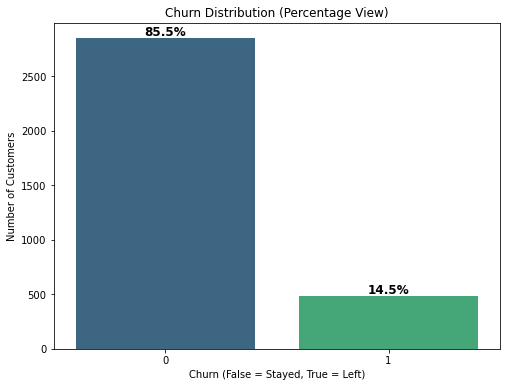

In [31]:
#Checking dataset imbalance 
# Calculate total using percentage to give a clear visuals and explanation
total = len(telecom_syria)
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='churn', data=telecom_syria, palette='viridis')

# Annotate with percentages instead of raw counts
for p in ax.patches:
    percentage = (p.get_height() / total) * 100
    ax.annotate(f'{percentage:.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=12, fontweight='bold')

plt.title('Churn Distribution (Percentage View)')
plt.xlabel('Churn (False = Stayed, True = Left)')
plt.ylabel('Number of Customers')
plt.show()

#Insights from imbalance check.

1. This data is significantly imbalanced with 85.5% non-exits and 14.5% exits.
2. This imbalance can bias our models towards prediciting majority class affecting detection of actual exits.
3. We fix this with recall and F1-score rather than focusing on accuracy.

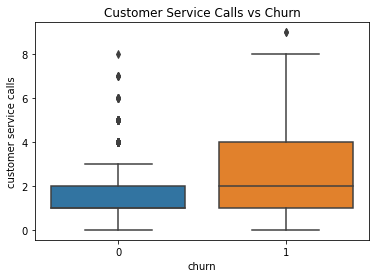

In [33]:
#Customer Service calls vs Exits
sns.boxplot(x='churn', y='customer service calls', data=telecom_syria)
plt.title('Customer Service Calls vs Churn')
plt.show()

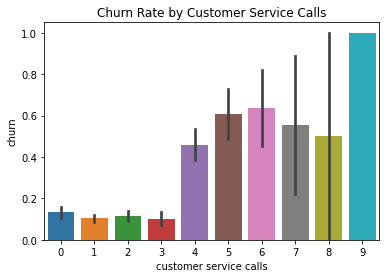

In [26]:
sns.barplot(x='customer service calls', y='churn', data=telecom_syria)
plt.title("Churn Rate by Customer Service Calls")
plt.show()

#Insights from Customer Experience  

Customers who exit show a significant higher intercation with customer care, this could indicate early warning signal.

In [34]:
#International Plans comparison with Exits
exit_rates = pd.crosstab(telecom_syria['international plan'], 
                          telecom_syria['churn'], 
                          normalize='index') * 100

# Plotting
churn_rates.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#345f78', '#4bb082'])
plt.title('Churn Rate: International Plan vs No Plan')
plt.ylabel('Percentage of Customers (%)')
plt.xlabel('International Plan (0 = No, 1 = Yes)')
plt.legend(title='Churn', labels=['Stayed', 'Exited'])
plt.xticks(rotation=0)
plt.show()

NameError: name 'churn_rates' is not defined

#Insights from international calls usage patterns
1. The data suggests while majority do not have international plan, those who do exit at higher rate. 
2. Having an international plan makes a customer x4times likely to exit at 42%.
3. What are the driving factors, price, competition, plan offers.
4. Indicates International plan problem/challenge. 

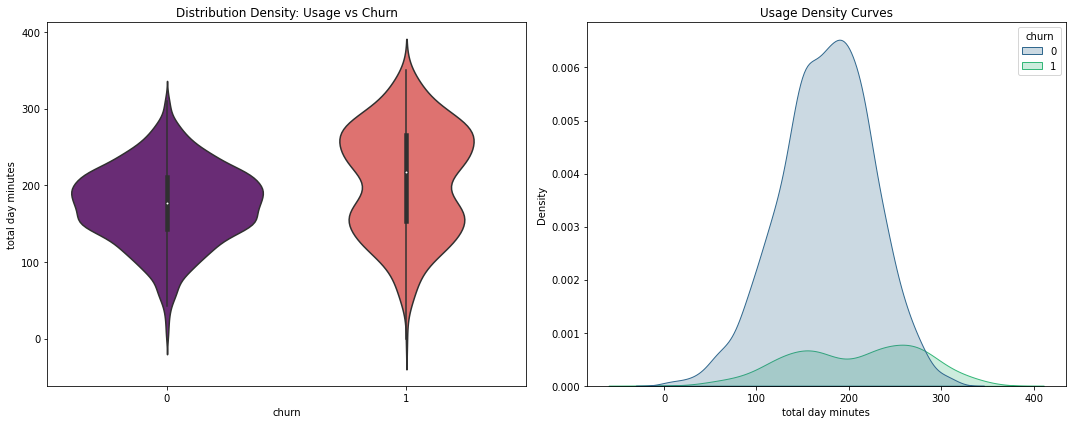

In [28]:
# Day usage patterns vs Exits 

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Violin Plot: Shows the distribution 'thickness'
sns.violinplot(x='churn', y='total day minutes', data=telecom_syria, ax=axes[0], palette='magma')
axes[0].set_title('Distribution Density: Usage vs Churn')

# 2. KDE Plot: Perfect for seeing the "overlap"
sns.kdeplot(data=telecom_syria, x='total day minutes', hue='churn', fill=True, palette='viridis', ax=axes[1])
axes[1].set_title('Usage Density Curves')

plt.tight_layout()
plt.show()

#Insights from usage patterns
1. The exiters exhibit an interesting pattern based on data/minutes usage, the dark green and red show two humps at 150Minutes and at 260minutes. Therefore high usage customers under this bracket vulnerable to exit.
2. These customers are SyriaTel valuable assets, suggets heavy data usage are expensive or uncompetitive to other users.
3. Once a customer exceeds 250 minutes, there is a probability of exit. 
4. Customer loyalty plans, retention strategies should be explored. 

ValueError: Could not interpret input 'total_minutes'

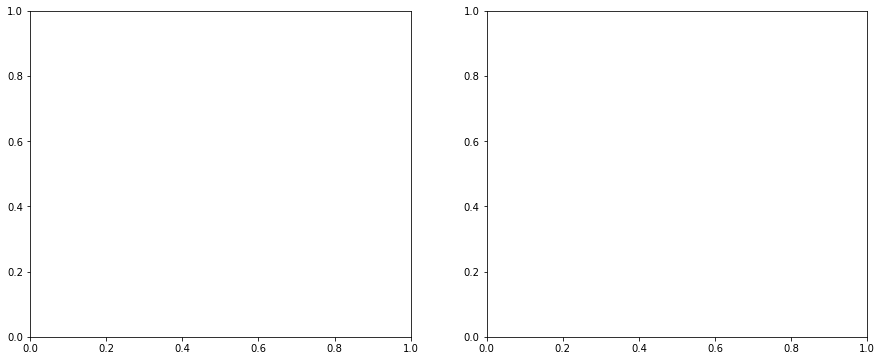

In [29]:
#Total usage patterns and exits 

# Assuming'total_minutes' is a sum of day, eve, night, and intl minutes
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Violin Plot: Shows the quartile ranges AND the density width
sns.violinplot(x='churn', y='total_minutes', data=telecom_syria, 
               ax=axes[0], palette='magma', inner='quartile')
axes[0].set_title('Violin Plot: Total Usage Distribution')

# 2. KDE Plot: Shows exactly where the two groups overlap or diverge
sns.kdeplot(data=telecom_syria, x='total_minutes', hue='churn', 
            fill=True, palette='viridis', ax=axes[1])
axes[1].set_title('Usage Density: Probability of Churn')

plt.tight_layout()
plt.show()

#Insights from Total minutes usage behaviour 
1. The exit zone is where the usage density of exiters cross the line with loyal customers, depicts statistical threshold where anyone on the right is more likely to exit. 
2. The safe bull the violin (left) shows majority at between 500-600minutes. 
3. Customer retention of safe bulk zone is imperative. 

In [ ]:
#Correlation heat map of target vs features 

# Select only numeric columns for correlation
corr = telecom_syria.select_dtypes(include=[np.number]).corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))

# Plot with annotations and a mask
sns.heatmap(corr, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            center=0,
            linewidths=.5, 
            cbar_kws={"shrink": .8})

plt.title('Improved Correlation Heatmap (Triangle View)')
plt.show()

#Insights from correlation heat map
1. The red spots of 1.0% and 96% show features saying the same thing, suggest they anbe dropped to avoid multicolliniality.
2. The 'Churn' row is the most import and it shows the key drivers of exits, International plan (26%), day usage pattern 21%, customer calls 21%.
3. Suggests feature engineering of some cloumns to get ratios(total minutes, international usage intensity)

In [ ]:
#Voicemail vs exits 
#Since it has a negative correlation from the heatmap it's important we get insights why. 

# 1. Churn Rate by Voicemail Plan (Percentage)
vmail_exits = pd.crosstab(telecom_syria['voice mail plan'], 
                          telecom_syria['churn'], 
                          normalize='index') * 100

# 2. Visualizing the results
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Plot A: Stacked Bar Chart for Churn Rate
vmail_exits.plot(kind='bar', stacked=True, color=['#345f78', '#4bb082'], ax=ax[0])
ax[0].set_title('Churn Rate: Voicemail Plan vs No Plan')
ax[0].set_ylabel('Percentage (%)')
ax[0].set_xticklabels(['No Plan', 'Plan'], rotation=0)

# Plot B: Boxplot for Message Count (Only for those with plans)
vmail_users = telecom_syria[telecom_syria['number vmail messages'] > 0]
sns.boxplot(x='churn', y='number vmail messages', data=vmail_users, palette='viridis', ax=ax[1])
ax[1].set_title('Voicemail Messages vs Churn (Plan Holders Only)')

plt.tight_layout()
plt.show()

#Insights from voicemael plan
1. Customers with voicemail plan had lower exit rates at 8-10% than those without at 15-17%
2. Suggests having a voicemail plan builds loyalty.
3. Paradox exists when compared with boxplot that shows the exiters had a higher median number of voicemail at ~31.
4. The higher message exiter could suggest may be competition due to better prices or reliance on other forms of communciation. 
5. Voicemail bundling with other plans or packages could lead to customer retention. 

# EDA Summary 

The data exploratory analysis reveals that customer exits are directly correlated with service dissatisfaction (measured through customer service calls), usage behavior, and service plan characteristics. 

The dataset is imbalanced, necessitating appropriate handling during modeling. 

Additionally, correlations among usage and charge variables highlight the need for feature selection to avoid redundancy.

# Data Modelling

In [ ]:
#The data set was taken through feature engineering  to improve signal, remove noise, and make patterns easier for the model to learn.

#International usage:(Int plan, total calls and minutes): without a plan they can be expensive and lead to exit.
#a new column that looks at a pattern of international usage was created and combined data set in int columns
telecom_syria['intl_usage_intensity'] = telecom_syria['total intl minutes'] / (telecom_syria['total intl calls'] + 1)

#usage patterns are very usefull, raw values given are okay but the behaviour is what leads to exit.
#How does the customer use the service, not just about how much he/she spent. 
telecom_syria['total_minutes'] = telecom_syria['total day minutes'] + telecom_syria['total eve minutes'] + telecom_syria['total night minutes']
telecom_syria['day_ratio'] = telecom_syria['total day minutes'] / telecom_syria['total_minutes']
telecom_syria['eve_ratio'] = telecom_syria['total eve minutes'] / telecom_syria['total_minutes']
telecom_syria['night_ratio'] = telecom_syria['total night minutes'] / telecom_syria['total_minutes']

#Charges will be dropped as they usage can be derived from minutes of the calls. 

#Voice mail behaviours and total voice mail messages are related they indicate dropped calls. 
telecom_syria['vmail_usage'] = telecom_syria['number vmail messages'] * (telecom_syria['voice mail plan'] == 'Yes')

#Account length tell about loyalty and tenure. 
telecom_syria['is_new_customer'] = (telecom_syria['account length'] < 12).astype(int)


In [ ]:
#Selecting the target (y) and features (x)
# Y is the target (what we want to know)the exits 
y = telecom_syria['churn'] 

# X is the data we use to know why the exists 
X = telecom_syria.drop(columns=['churn'])

In [14]:
#Data Splitting Tran-Test Split # Data Scaling 
#Splitting data 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

#Scaling our dataset

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) #fiting ONLY on train
X_test_scaled = scaler.transform(X_test) #transform test 

#Base model 
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

#Predictions 
y_pred = model.predict(X_test_scaled)

#model evaluation 
print(classification_report(y_test, y_pred))

NameError: name 'X' is not defined

#key insights from splitting, scaling, and modelling
#For loyal customers 
1. Accuracy is at 78% this is caused by data imbalance identified earlier
2. Precision at 95% means that the model prediction will be 95% correct for customers who stay. 
3. For Recall is correctly identifies 78% of customers who decides to stay.
4. For the F1 it shows that there strong performance for the customers who stay.
5. Inclussion, our model is very reliable at identifying loyal customers but its classifying some as exiters. 

#For exiters 
1. The model predicts that customer will exit at 38% accuracy, this means many false positives.
2. For recall on exiters, the model correctly identifies 76% of actual exiters such a good %. 
3. F1 at at 50% is moderate balanace between precisionn and recall. 

Conclusion

Conclusion is that the model successfully catched 76% of the customers exiting thus relating to our business problem and objectives. 

However, the many false positive at 38% suggests that some customers flagged may not actually exit. Its more of a trade-off than a bad thing, because in telecoms the cost of missing a customer exiting is higher than acquistion of one. 

In [ ]:
#To improve collinearity we drop some columns
#they are duplicates of minutes and may affect our data by causing multicollinearity 
drop_columns = X.drop(columns=[
    'total day charge', 
    'total eve charge', 
    'total night charge', 
    'total intl charge'
], errors='ignore')

In [ ]:
#Improving our model 
#The logisticRegression model needs to be improved through either decisin tree
#The objective here is to capture non-linear patterns remember there are patterns that precipitate exits. 
#This also improves precision and how to interprete the results. 

#We use the previous train-test-split code (X_train, X_test not the scaled dataset)
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

#Prediciting the decision tree model
y_pred_decision_tree_model = decision_tree_model.predict(X_test)

#Evaluation the decision tree model 
print(classification_report(y_test, y_pred_decision_tree_model))



#Insights before the model
1. Our recall has improved to 95% to correctly detect loyal customers, 

In [ ]:
#Improving our model (tuning)

#Decision tree 
dt_tuned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42)
dt_tuned.fit(X_train, y_train)

#predicting the decision_tree_tuned model 
y_pred_dt_tuned = dt_tuned.predict(X_test)

print(classification_report(y_test, y_pred_dt_tuned))

plt.figure(figsize=(20,10))

plot_tree(
    dt_tuned,
    feature_names=X.columns,
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Visualization")
plt.show()


#Comparing the two models Logistic regression and Decision Tree models
1. The dt_model improved the prediction that customers will exit from 38% to 68% thus making reliable predictions, by reducing many false postives. 
2. For recall on exiters the dt_model dropped slightly to 73% prediction to catch exiters, a slight trade-off with better precision. 
3. F1 score registers major improvement, from 50%-70% meaning a much better balance between precision and recall. 
4. Accuracy had a huge jump from 78% to 91% 

#Conlusion
#Final Model Selection
The tuned decision tree model was selected as the final model due to its superior balance between precision and recall. It provides more accurate and actionable predictions, enabling SyriaTel to target high-risk customers more effectively while reducing unnecessary retention efforts.”


In [ ]:
feature_importance = pd.Series(
    dt_tuned.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

feature_importance.head(10).plot(kind='bar')
plt.title('Top Features Driving Churn')
plt.show()

#Key insights from feature importance visualization
1. Key reasons driving customers to exit SyriaTel is customer service at 24%, international plan 20%, and total minutes 16% total charges at 18%
2. Important to classify type or reasons for customer service calls. 

#Hyperparameter Tuning (Grid Search)

#To further improve model performance, hyperparameter tuning was considered as it evaluates parameter combinations using cross validation to identify the optimal configuration.
#Recall was selected to ensure model optimization as it identifies cuctomers likely to exit which is critical business question and intervention

In [ ]:
#Hyperparameter Tuning 
#Base model 
dt = DecisionTreeClassifier(random_state=42)

#Parameters grid 
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'class_weight': [None, 'balanced']
}
#initiate model 
dt = DecisionTreeClassifier(random_state=42)
                            
#Run GridSearch #Optimize call for recall the one we prioritized. 

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

#best parameters 
print("Best Parameters:", grid_search.best_params_)

#best model 
best_dt = grid_search.best_estimator_

#Evaluate tunes model
y_pred_best = best_dt.predict(X_test)

print(classification_report(y_test, y_pred_best))

#Compare scores 
print("Best CV Score (Recall):", grid_search.best_score_)

#Hyperparameter tuning insights 
1. The class weight is balanced meaning the model is giving more importance to exiters, this aligns well to the earlier imbalance of 85/5% vs 14.5%
2. The max depth = 5 showing exit patterns can be detected and not complex to resolve.
3. The hyperparameter tunimg model precision 66% of predicted exiters correct, recall at 73% of actual exiters detected and relative F1 score of 69%
4. Shows strong reduction of false positives without affecting ability of the model to detect exiters. 
5. Exit patters are structured ad depth of 5 and its a combination of patters not single feature/variable
6. Behaviour patterns are the indicators of customer exits. 

#Conclusion
The model has demostrated that a majority of customers are at risk of exiting while maintaining a relatively low false positive rate. Syriatel shud target high-risk customers more efficiently and with targetted retention approaches at the sametime going after potential customers exiting. 

# Final insights 

1. Customer exits are strongly linked to customer dissastifaction and usage behaviour, international calls without a plan, may be high day time charges or minutes. 
2. The key drivers of exiting is dissatisfaction, pricing/usage patterns. 
3. The decsion tree model accuracy of 91 indicates that SyriaTel can detect high risk customers before exits and prioritize retention. 

# Recommendations 

1. Strategic retention strategy that target customers usage patterns like improved plans, charges and minutes. 
2. Improve customer experience, for example fast resolutions of customer complains, monitor customers with repeated complaints or areas with low coverage affecting service delivery. 
3. Optimize on price, minutes, and plan to offer better packages like international plans or day time offers. 
4. Customer acquistion should be prioritized, review onboarding experience and improve new customer incentives for a period. 
5. Targetted marketting focusing on high-risk customers and loyal customers. 
6. Integrate daily/weekly exit scoring and link it to customer experience teams to follow up. 

# Conlusion 

This data analysis has successfully demomstrated and developed that a machine learning model capable of predicting customer exits with strong performance. The tuned decision tree model provided the best balance between identifying at-risk customers and minimizing false alarms.”

The analysis shows that customer exits is largely influenced by service experience, usage behavior, and customer tenure rather than simple demographic factors. Importantly, the model demonstrates that exits are predictable and can be proactively managed and retention efforts prioritized. 

By leveraging these insights, SyriaTel can transition from a reactive to a proactive customer retention strategy, significantly reducing customer attrition and associated revenue loss.”